In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("hotel_bookings.csv")

# Missing value handling
df['children'].fillna(0, inplace=True)
df['country'].fillna(df['country'].mode()[0], inplace=True)
df['agent'].fillna(0, inplace=True)
df['company'].fillna(0, inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

# Feature Engineering
df['total_guests'] = (
    df['adults'] +
    df['children'] +
    df['babies']
)

df['total_stay'] = (
    df['stays_in_weekend_nights'] +
    df['stays_in_week_nights']
)

df['is_family'] = np.where(df['total_guests'] > 2, 1, 0)

df['revenue'] = df['adr'] * df['total_stay']

print("Dataset ready for EDA")

Dataset ready for EDA


/tmp/ipykernel_6588/3008216186.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['children'].fillna(0, inplace=True)
/tmp/ipykernel_6588/3008216186.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'd

In [ ]:
df = pd.read_csv("hotel_bookings.csv")

In [ ]:
plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

<Figure size 1000x600 with 0 Axes>

EDA SECTION 1 — CANCELLATION ANALYSIS
1. Booking Cancellation Distribution

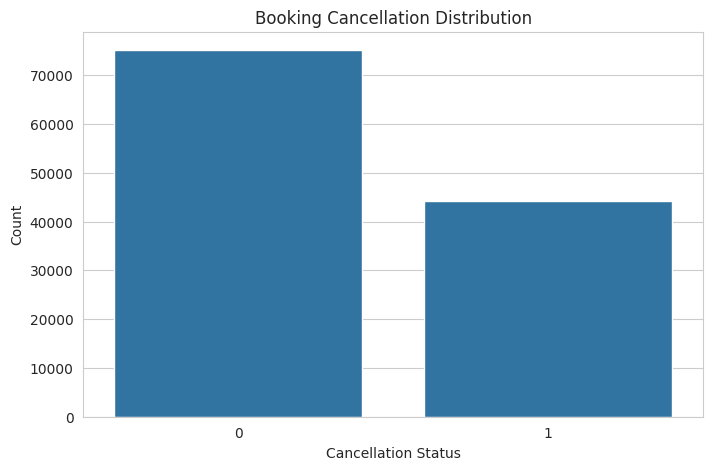

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(x='is_canceled', data=df)

plt.title("Booking Cancellation Distribution")
plt.xlabel("Cancellation Status")
plt.ylabel("Count")

plt.show()

BUSINESS INSIGHT

Write in report:

The visualization shows the proportion of canceled and non-canceled bookings. This helps identify the severity of cancellation-related revenue loss in the hospitality sector.

EDA SECTION 2 — HOTEL TYPE ANALYSIS

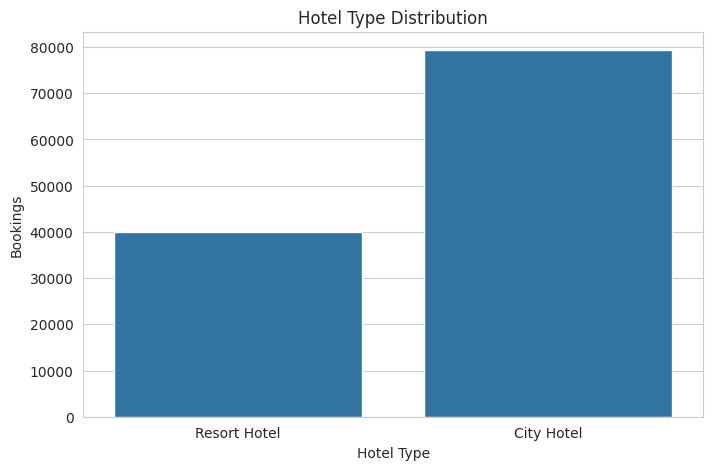

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(x='hotel', data=df)

plt.title("Hotel Type Distribution")
plt.xlabel("Hotel Type")
plt.ylabel("Bookings")

plt.xticks(rotation=0)

plt.show()

EDA SECTION 3 — MONTHLY BOOKING TREND

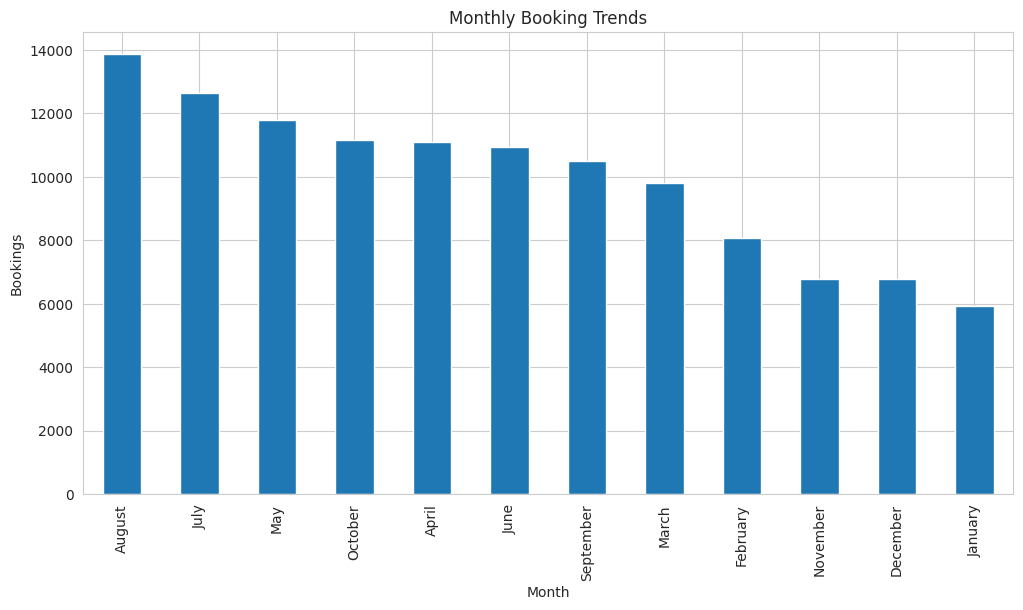

In [ ]:
monthly_bookings = df['arrival_date_month'].value_counts()

plt.figure(figsize=(12,6))

monthly_bookings.plot(kind='bar')

plt.title("Monthly Booking Trends")
plt.xlabel("Month")
plt.ylabel("Bookings")

plt.show()

EDA SECTION 4 — ADR ANALYSIS

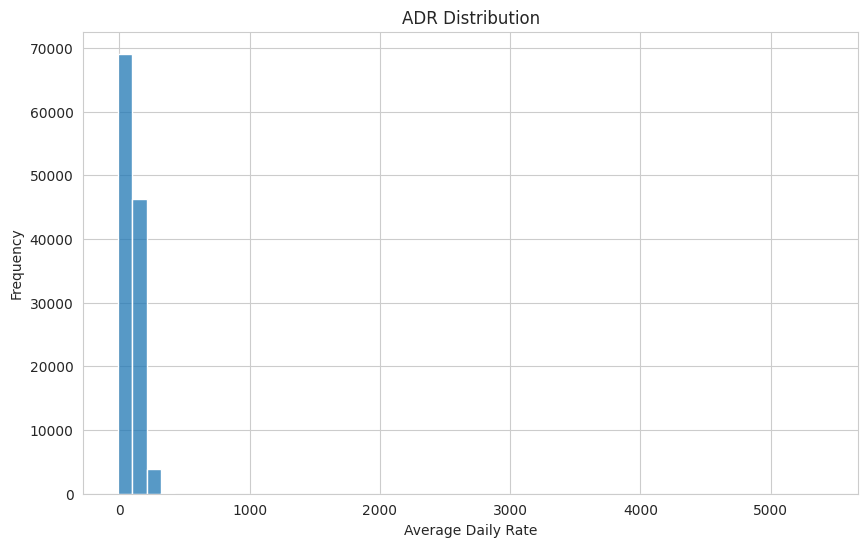

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(df['adr'], bins=50)

plt.title("ADR Distribution")
plt.xlabel("Average Daily Rate")
plt.ylabel("Frequency")

plt.show()

EDA SECTION 5 — LEAD TIME VS CANCELLATION

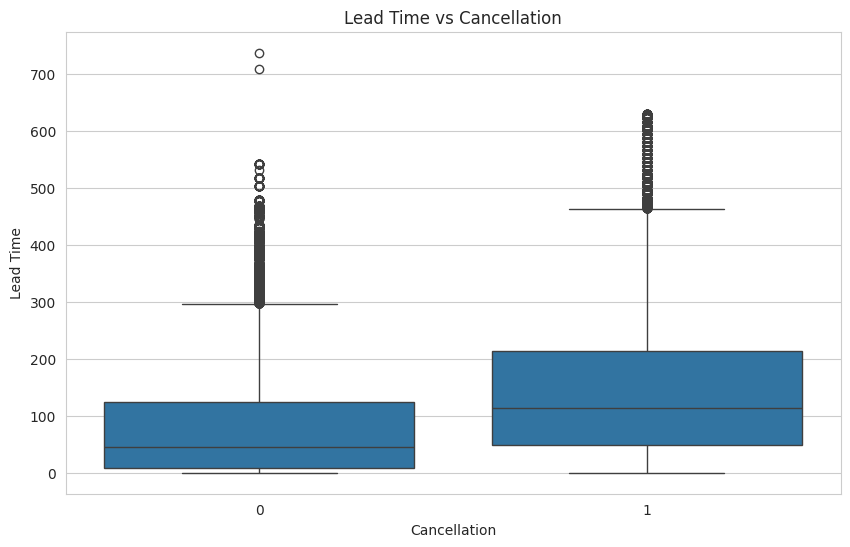

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(x='is_canceled', y='lead_time', data=df)

plt.title("Lead Time vs Cancellation")
plt.xlabel("Cancellation")
plt.ylabel("Lead Time")

plt.show()

BUSINESS INSIGHT

This is powerful.

Add in report:

Customers with higher lead times show a greater tendency toward booking cancellation.

EDA SECTION 6 — COUNTRY ANALYSIS

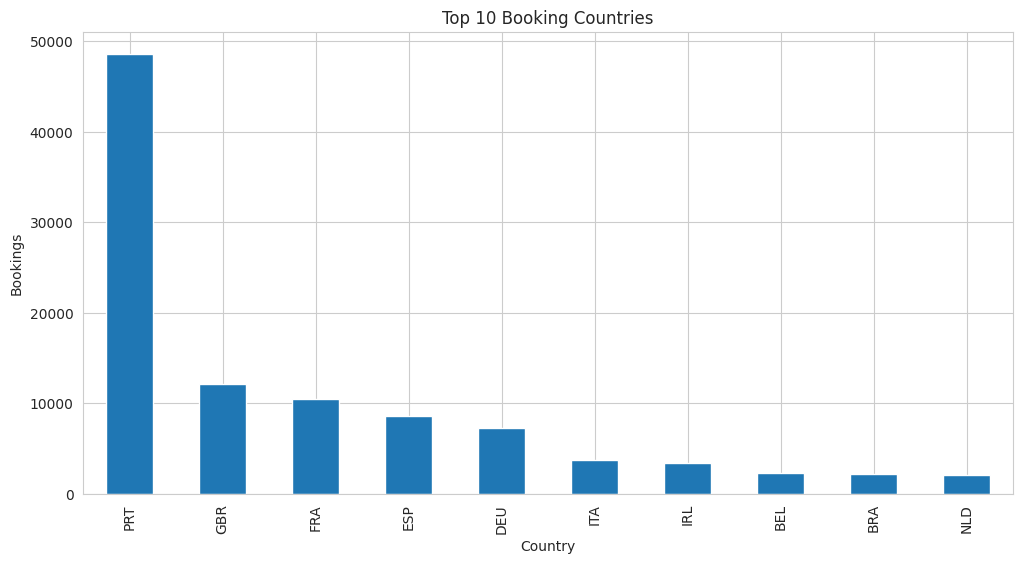

In [ ]:
top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(12,6))

top_countries.plot(kind='bar')

plt.title("Top 10 Booking Countries")
plt.xlabel("Country")
plt.ylabel("Bookings")

plt.show()

EDA SECTION 7 — CUSTOMER TYPE ANALYSIS

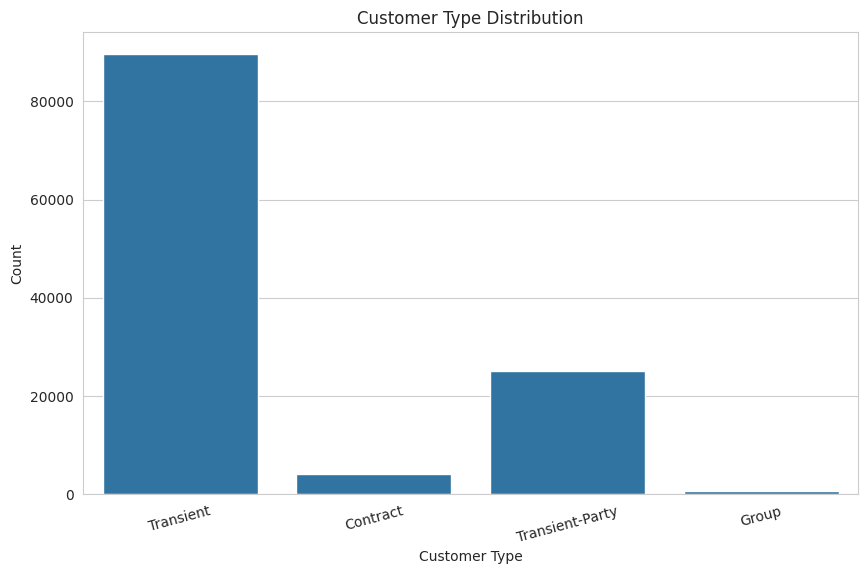

In [ ]:
plt.figure(figsize=(10,6))

sns.countplot(x='customer_type', data=df)

plt.title("Customer Type Distribution")
plt.xlabel("Customer Type")
plt.ylabel("Count")

plt.xticks(rotation=15)

plt.show()

EDA SECTION 8 — REVENUE ANALYSIS

In [ ]:
df['revenue'] = df['adr'] * (
    df['stays_in_weekend_nights'] +
    df['stays_in_week_nights']
)

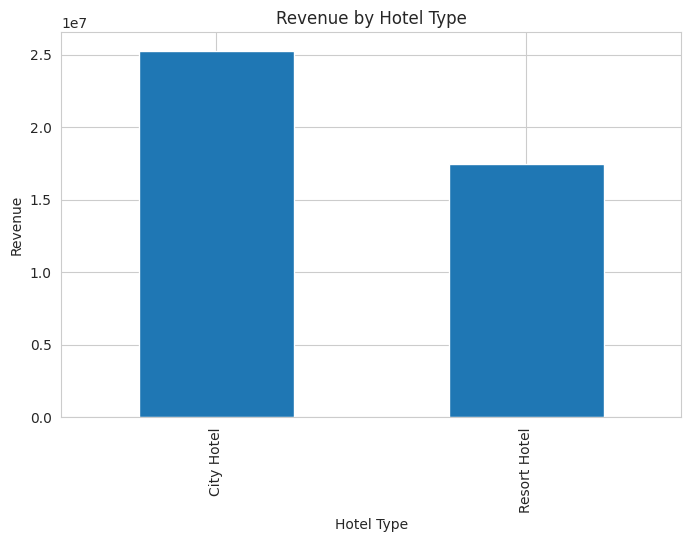

In [ ]:
hotel_revenue = df.groupby('hotel')['revenue'].sum()

plt.figure(figsize=(8,5))

hotel_revenue.plot(kind='bar')

plt.title("Revenue by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Revenue")

plt.show()

EDA SECTION 9 — CORRELATION HEATMAP

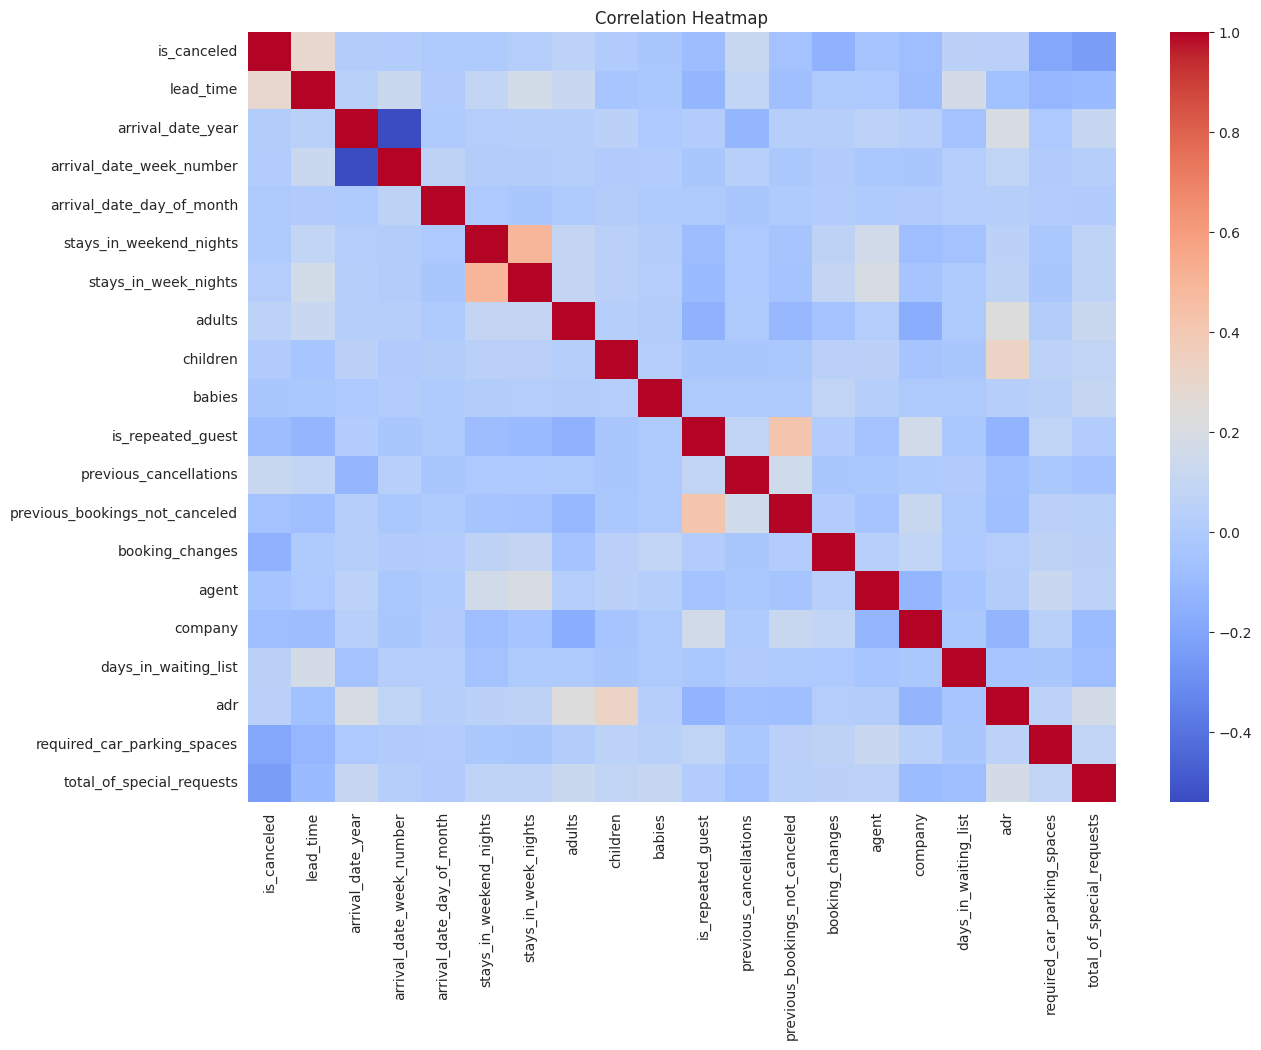

In [ ]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(14,10))

sns.heatmap(numeric_df.corr(), cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

plt.savefig("outputs/graph_name.png")
plt.show()